# 04 — PCA Baseline Experiment

Applies **PCA dimensionality reduction** at 10/20/30/40/50 components on two input
spaces and compares against the original 110-D XP coefficients using **10 classifiers**.

### Motivation

The polynomial experiment (`02_classify`) showed that polynomial bases (Chebyshev,
Hermite, Laguerre, Legendre) underperform the original 110-D coefficients. PCA is
the standard data-driven baseline to disentangle two questions:
- **Can we reduce 110 dimensions to fewer while preserving classification power?**
- **Are polynomial bases a good way to do it, or is the problem reduction itself?**

### Experimental grid

- **Group A — PCA on 110-D XP coefficients**: `og_xp_110` + `pca_xp_{10,20,30,40,50}`
- **Group B — PCA on 343-D sampled spectra**: `pca_spec_{10,20,30,40,50}`
- **10 classifiers**: LR, SVM (RBF), Random Forest, XGBoost, KNN, LDA, Gaussian NB, AdaBoost, MLP, Extra Trees
- **5 random train/test splits** (shared with `02_classify` for direct comparability)

### Target: Article Baseline (Table 2)

| Model | Threshold | Sensitivity | Specificity | Precision |
|-------|-----------|------------|------------|----------|
| CNN Binary (Youden) | 0.295 | **0.878** | 0.965 | **0.838** |
| CNN Binary (F₁)     | 0.745 | 0.818     | 0.985 | 0.920     |

**Primary metrics: Sensitivity and Precision.**

In [20]:
import csv
import json
import time
import warnings
from pathlib import Path

import matplotlib
# matplotlib.use("Agg")  # uncomment only for headless/script execution

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.calibration import CalibratedClassifierCV
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    RandomForestClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    confusion_matrix,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from scipy.stats import uniform, loguniform
from xgboost import XGBClassifier

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports OK.")

Imports OK.


In [21]:
EXPERIMENT_DIR = Path.cwd() if Path("data").exists() else Path("transformation_experiment")
DATA_DIR = EXPERIMENT_DIR / "data"
RESULTS_DIR = EXPERIMENT_DIR / "results"
RESULTS_DIR.mkdir(exist_ok=True)

POC_DIR = Path.cwd().parent / "transformation_poc" if Path("data").exists() else Path("transformation_poc")

print("Data dir:      ", DATA_DIR.resolve())
print("Results dir:   ", RESULTS_DIR.resolve())
print("PoC dir:       ", POC_DIR.resolve())

Data dir:       /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/data
Results dir:    /Users/erikak/Documents/uni/bakalauras/kodas/transformation_experiment/results
PoC dir:        /Users/erikak/Documents/uni/bakalauras/kodas/transformation_poc


In [22]:
with open(DATA_DIR / "splits.json") as f:
    splits = json.load(f)

df_xp = pd.read_csv(DATA_DIR / "og_xp.csv")
xp_feat_cols = [c for c in df_xp.columns if c not in ("source_id", "y")]
X_xp = df_xp[xp_feat_cols].to_numpy(dtype=np.float64)
y_all = df_xp["y"].to_numpy(dtype=int)

df_spec = pd.read_csv(POC_DIR / "xp_sampled_spectra.csv")
spec_feat_cols = [c for c in df_spec.columns if c not in ("source_id", "y")]
X_spec = df_spec[spec_feat_cols].to_numpy(dtype=np.float64)

print(f"Loaded {len(splits)} splits")
print(f"XP coefficients: {X_xp.shape} (samples × features)")
print(f"Sampled spectra: {X_spec.shape} (samples × wavelength bins)")
print(f"Class balance: {(y_all == 0).sum()} neg / {(y_all == 1).sum()} pos")

Loaded 10 splits
XP coefficients: (2815, 110) (samples × features)
Sampled spectra: (2815, 343) (samples × wavelength bins)
Class balance: 2257 neg / 558 pos


## 1. PCA Variance Analysis

Before running any classifiers, examine how much variance PCA captures
at each dimensionality in both input spaces.

In [23]:
PCA_DIMS = [10, 20, 30, 40, 50]

scaler_xp = StandardScaler().fit(X_xp)
X_xp_sc = scaler_xp.transform(X_xp)

scaler_spec = StandardScaler().fit(X_spec)
X_spec_sc = scaler_spec.transform(X_spec)

pca_full_xp = PCA(random_state=RANDOM_STATE).fit(X_xp_sc)
pca_full_spec = PCA(random_state=RANDOM_STATE).fit(X_spec_sc)

cum_var_xp = np.cumsum(pca_full_xp.explained_variance_ratio_)
cum_var_spec = np.cumsum(pca_full_spec.explained_variance_ratio_)

rows = []
for k in PCA_DIMS:
    rows.append({
        "n_components": k,
        "xp_110d_cumvar": cum_var_xp[k - 1],
        "spec_343d_cumvar": cum_var_spec[k - 1],
    })

df_var = pd.DataFrame(rows)
df_var.to_csv(RESULTS_DIR / "pca_variance_explained.csv", index=False)

print("Cumulative variance explained:")
print(df_var.to_string(index=False, float_format="{:.4f}".format))

Cumulative variance explained:
 n_components  xp_110d_cumvar  spec_343d_cumvar
           10          0.3585            1.0000
           20          0.4989            1.0000
           30          0.6122            1.0000
           40          0.7072            1.0000
           50          0.7874            1.0000


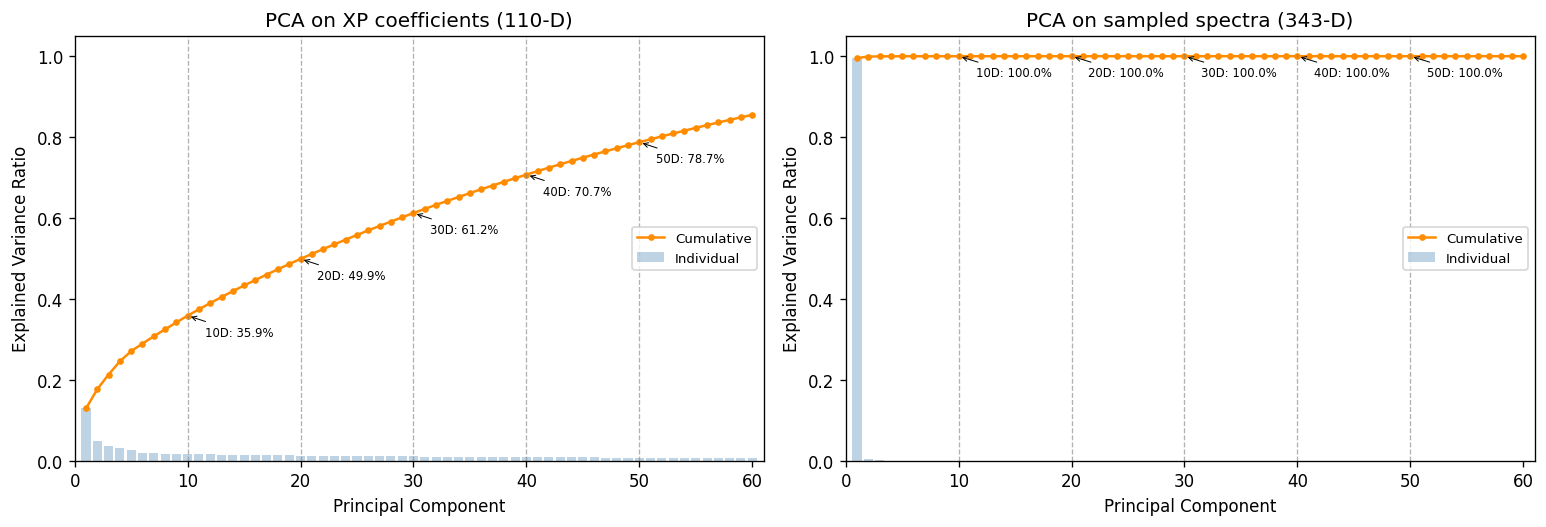

Saved → results/pca_scree_plot.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, cum_var, indiv_var, title, n_total in [
    (axes[0], cum_var_xp, pca_full_xp.explained_variance_ratio_,
     f"PCA on XP coefficients (110-D)", 110),
    (axes[1], cum_var_spec, pca_full_spec.explained_variance_ratio_,
     f"PCA on sampled spectra (343-D)", 343),
]:
    n_show = min(60, n_total)
    comps = np.arange(1, n_show + 1)

    ax.bar(comps, indiv_var[:n_show], alpha=0.35, label="Individual", color="steelblue")
    ax.plot(comps, cum_var[:n_show], "o-", ms=3, color="darkorange", label="Cumulative")

    for k in PCA_DIMS:
        if k <= n_show:
            ax.axvline(k, ls="--", lw=0.8, color="gray", alpha=0.6)
            ax.annotate(
                f"{k}D: {cum_var[k-1]:.1%}",
                xy=(k, cum_var[k - 1]),
                xytext=(k + 1.5, cum_var[k - 1] - 0.05),
                fontsize=7,
                arrowprops=dict(arrowstyle="->", lw=0.6),
            )

    ax.set_xlabel("Principal Component")
    ax.set_ylabel("Explained Variance Ratio")
    ax.set_title(title)
    ax.legend(loc="center right", fontsize=8)
    ax.set_xlim(0, n_show + 1)
    ax.set_ylim(0, 1.05)

fig.tight_layout()
fig.savefig(RESULTS_DIR / "pca_scree_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/pca_scree_plot.png")

### Interpretation: why spectra reach 100% variance at just 10 components

The sampled spectra are **reconstructed from the XP coefficients** via `gaiaxpy.calibrate()` —
a linear transformation of 110 basis-function coefficients evaluated at 343 wavelength points.
Because Gaia XP is a low-resolution spectrograph, the resulting spectra are inherently smooth:
neighboring wavelength bins are nearly perfectly correlated, and the 343-D space is massively
oversampled relative to the instrument's actual information content. Hence ~10 PCA components
already capture effectively all the variance.

The XP coefficients tell a different story: after `StandardScaler` normalises every dimension
to unit variance, the tiny high-order coefficients (bp_40 … bp_54, rp_40 … rp_54) — which are
mostly instrumental noise — get inflated to equal importance. PCA then needs many components
to "explain" this noise, which is why 10 PCs capture only ~36% and even 50 PCs reach only ~79%.

**Consequence for classification:** PCA on spectra is essentially lossless at all tested
dimensionalities — any performance difference from the full 110-D baseline is due to the
representation change, not information loss. PCA on XP coefficients is a genuinely lossy
compression, so performance degradation there may simply reflect discarded variance.

## 2. Define representations and classifiers

In [25]:
REPRESENTATIONS = [
    {"name": "og_xp_110", "X": X_xp, "n_features": 110, "pca_k": None},
]

for k in PCA_DIMS:
    REPRESENTATIONS.append(
        {"name": f"pca_xp_{k}", "X": X_xp, "n_features": k, "pca_k": k}
    )

for k in PCA_DIMS:
    REPRESENTATIONS.append(
        {"name": f"pca_spec_{k}", "X": X_spec, "n_features": k, "pca_k": k}
    )

print(f"{len(REPRESENTATIONS)} representations:")
for r in REPRESENTATIONS:
    pca_label = f"PCA→{r['pca_k']}" if r["pca_k"] else "none"
    print(f"  {r['name']:20s}  input={r['X'].shape[1]:4d}D  output={r['n_features']:3d}  PCA={pca_label}")

11 representations:
  og_xp_110             input= 110D  output=110  PCA=none
  pca_xp_10             input= 110D  output= 10  PCA=PCA→10
  pca_xp_20             input= 110D  output= 20  PCA=PCA→20
  pca_xp_30             input= 110D  output= 30  PCA=PCA→30
  pca_xp_40             input= 110D  output= 40  PCA=PCA→40
  pca_xp_50             input= 110D  output= 50  PCA=PCA→50
  pca_spec_10           input= 343D  output= 10  PCA=PCA→10
  pca_spec_20           input= 343D  output= 20  PCA=PCA→20
  pca_spec_30           input= 343D  output= 30  PCA=PCA→30
  pca_spec_40           input= 343D  output= 40  PCA=PCA→40
  pca_spec_50           input= 343D  output= 50  PCA=PCA→50


In [26]:
N_ITER = 30
INNER_CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

CLASSIFIERS = [
    {
        "name": "LogisticRegression",
        "estimator": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        "needs_scaler": True,
        "params": {
            "clf__C": loguniform(1e-3, 1e3),
            "clf__penalty": ["l1", "l2"],
            "clf__solver": ["saga"],
            "clf__class_weight": [None, "balanced"],
        },
    },
    {
        "name": "SVM_RBF",
        "estimator": SVC(probability=False, random_state=RANDOM_STATE),
        "needs_scaler": True,
        "needs_calibration": True,
        "params": {
            "clf__C": loguniform(1e-2, 1e3),
            "clf__gamma": loguniform(1e-4, 1e1),
            "clf__class_weight": [None, "balanced"],
        },
    },
    {
        "name": "RandomForest",
        "estimator": RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "needs_scaler": False,
        "params": {
            "clf__n_estimators": [100, 300, 500],
            "clf__max_depth": [None, 10, 20, 30],
            "clf__min_samples_leaf": [1, 2, 5],
            "clf__max_features": ["sqrt", "log2", 0.3],
            "clf__class_weight": [None, "balanced"],
        },
    },
    {
        "name": "XGBoost",
        "estimator": XGBClassifier(
            eval_metric="logloss",
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        ),
        "needs_scaler": False,
        "params": {
            "clf__n_estimators": [100, 300, 500],
            "clf__max_depth": [3, 5, 7, 10],
            "clf__learning_rate": loguniform(0.01, 0.3),
            "clf__subsample": uniform(0.6, 0.4),
            "clf__colsample_bytree": uniform(0.5, 0.5),
            "clf__scale_pos_weight": [1, 3, 4],
        },
    },
    {
        "name": "KNN",
        "estimator": KNeighborsClassifier(),
        "needs_scaler": True,
        "params": {
            "clf__n_neighbors": [3, 5, 7, 11, 15, 21],
            "clf__weights": ["uniform", "distance"],
            "clf__metric": ["euclidean", "manhattan"],
        },
    },
    {
        "name": "LDA",
        "estimator": LinearDiscriminantAnalysis(),
        "needs_scaler": True,
        "params": {
            "clf__solver": ["svd", "lsqr", "eigen"],
            "clf__shrinkage": [None, 0.1, 0.5, 0.9, "auto"],
        },
    },
    {
        "name": "GaussianNB",
        "estimator": GaussianNB(),
        "needs_scaler": True,
        "params": {
            "clf__var_smoothing": loguniform(1e-12, 1e-1),
        },
    },
    {
        "name": "AdaBoost",
        # Removed 'algorithm' parameter to avoid TypeError for scikit-learn >= 1.2
        "estimator": AdaBoostClassifier(random_state=RANDOM_STATE),
        "needs_scaler": False,
        "params": {
            "clf__n_estimators": [50, 100, 200, 500],
            "clf__learning_rate": loguniform(0.01, 2.0),
        },
    },
    {
        "name": "MLP",
        "estimator": MLPClassifier(max_iter=1000, random_state=RANDOM_STATE, early_stopping=True),
        "needs_scaler": True,
        "params": {
            "clf__hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
            "clf__alpha": loguniform(1e-5, 1e-1),
            "clf__learning_rate_init": loguniform(1e-4, 1e-2),
            "clf__activation": ["relu", "tanh"],
        },
    },
    {
        "name": "ExtraTrees",
        "estimator": ExtraTreesClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "needs_scaler": False,
        "params": {
            "clf__n_estimators": [100, 300, 500],
            "clf__max_depth": [None, 10, 20, 30],
            "clf__min_samples_leaf": [1, 2, 5],
            "clf__max_features": ["sqrt", "log2", 0.3],
            "clf__class_weight": [None, "balanced"],
        },
    },
]

print(f"{len(CLASSIFIERS)} classifiers: {[c['name'] for c in CLASSIFIERS]}")

10 classifiers: ['LogisticRegression', 'SVM_RBF', 'RandomForest', 'XGBoost', 'KNN', 'LDA', 'GaussianNB', 'AdaBoost', 'MLP', 'ExtraTrees']


## 3. Evaluation helpers

In [ ]:
def build_pipeline(clf_cfg, pca_k):
    """Build an sklearn Pipeline with optional scaler + optional PCA + classifier."""
    steps = []
    if clf_cfg["needs_scaler"]:
        steps.append(("scaler", StandardScaler()))
    if pca_k is not None:
        steps.append(("pca", PCA(n_components=pca_k, random_state=RANDOM_STATE)))
    steps.append(("clf", clf_cfg["estimator"]))
    return Pipeline(steps)


def pick_youden_threshold(y_true, y_prob, grid_size=200):
    """Pick threshold maximising Youden's J = Sensitivity + Specificity - 1."""
    thresholds = np.linspace(0, 1, grid_size)
    best_j, best_thr = -1, 0.5
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
        sens = tp / (tp + fn) if (tp + fn) else 0
        spec = tn / (tn + fp) if (tn + fp) else 0
        j = sens + spec - 1
        if j > best_j:
            best_j, best_thr = j, thr
    return best_thr


def evaluate(y_true, y_prob, threshold):
    """Compute all metrics at a given threshold."""
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sens = tp / (tp + fn) if (tp + fn) else 0.0
    spec = tn / (tn + fp) if (tn + fp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    acc  = (tp + tn) / (tp + tn + fp + fn)
    f1   = (2 * prec * sens) / (prec + sens) if (prec + sens) else 0.0
    youden = sens + spec - 1.0

    return {
        "threshold": threshold,
        "sensitivity": sens,
        "specificity": spec,
        "precision": prec,
        "accuracy": acc,
        "f1": f1,
        "youden_j": youden,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "brier": brier_score_loss(y_true, y_prob),
        "log_loss": log_loss(y_true, y_prob),
    }


def filter_params_for_lda(clf_cfg, params):
    """LDA shrinkage is only valid with 'lsqr' or 'eigen' solver, not 'svd'."""
    if clf_cfg["name"] != "LDA":
        return params
    filtered = dict(params)
    solver = filtered.get("clf__solver", "svd")
    if solver == "svd":
        filtered.pop("clf__shrinkage", None)
    return filtered


print("Evaluation helpers ready.")

## 4. Run experiment

For each (representation × classifier × split):
1. Build pipeline (scaler → PCA → classifier)
2. `RandomizedSearchCV` on training set (3-fold CV, ROC-AUC)
3. Pick Youden-optimal threshold on training predictions
4. Evaluate on held-out test set

In [ ]:
all_results = []

total_cells = len(REPRESENTATIONS) * len(CLASSIFIERS) * len(splits)
cell_idx = 0
t_start = time.time()

results_path = RESULTS_DIR / "pca_experiment_results.csv"
csv_columns = None

for repr_cfg in REPRESENTATIONS:
    X_all = repr_cfg["X"]
    pca_k = repr_cfg["pca_k"]

    for clf_cfg in CLASSIFIERS:
        for split_name, split_idx in splits.items():
            cell_idx += 1
            train_idx = np.array(split_idx["train"])
            test_idx  = np.array(split_idx["test"])

            X_tr, y_tr = X_all[train_idx], y_all[train_idx]
            X_te, y_te = X_all[test_idx],  y_all[test_idx]

            pipe = build_pipeline(clf_cfg, pca_k)

            search = RandomizedSearchCV(
                pipe,
                clf_cfg["params"],
                n_iter=N_ITER,
                cv=INNER_CV,
                scoring="roc_auc",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                error_score="raise",
            )

            try:
                search.fit(X_tr, y_tr)
            except Exception:
                # LDA: shrinkage incompatible with svd — retry without shrinkage params
                if clf_cfg["name"] == "LDA":
                    fallback_params = {"clf__solver": ["lsqr", "eigen"], "clf__shrinkage": [None, 0.1, 0.5, 0.9, "auto"]}
                    search = RandomizedSearchCV(
                        pipe, fallback_params,
                        n_iter=N_ITER, cv=INNER_CV, scoring="roc_auc",
                        random_state=RANDOM_STATE, n_jobs=-1, error_score="raise",
                    )
                    search.fit(X_tr, y_tr)
                else:
                    raise

            best_pipe = search.best_estimator_

            if clf_cfg.get("needs_calibration"):
                cal_pipe = CalibratedClassifierCV(best_pipe, cv=3, method="sigmoid")
                cal_pipe.fit(X_tr, y_tr)
                y_prob_tr = cal_pipe.predict_proba(X_tr)[:, 1]
                y_prob_te = cal_pipe.predict_proba(X_te)[:, 1]
            else:
                y_prob_tr = best_pipe.predict_proba(X_tr)[:, 1]
                y_prob_te = best_pipe.predict_proba(X_te)[:, 1]

            thr = pick_youden_threshold(y_tr, y_prob_tr)

            metrics = evaluate(y_te, y_prob_te, thr)
            metrics.update({
                "representation": repr_cfg["name"],
                "n_features": repr_cfg["n_features"],
                "classifier": clf_cfg["name"],
                "split": split_name,
                "best_cv_roc_auc": search.best_score_,
            })
            all_results.append(metrics)

            if csv_columns is None:
                csv_columns = list(metrics.keys())
                with open(results_path, "w", newline="") as f:
                    writer = csv.DictWriter(f, fieldnames=csv_columns)
                    writer.writeheader()
            with open(results_path, "a", newline="") as f:
                csv.DictWriter(f, fieldnames=csv_columns).writerow(metrics)

            elapsed = time.time() - t_start
            eta = (elapsed / cell_idx) * (total_cells - cell_idx)
            print(
                f"  [{cell_idx:3d}/{total_cells}]  {repr_cfg['name']:20s}  {clf_cfg['name']:20s}  "
                f"{split_name}  ROC-AUC={metrics['roc_auc']:.4f}  "
                f"Sens={metrics['sensitivity']:.4f}  "
                f"Prec={metrics['precision']:.4f}  ETA={eta/60:.1f}min",
                flush=True,
            )

elapsed_total = time.time() - t_start
print(f"\nFinished {total_cells} cells in {elapsed_total/60:.1f} minutes.")

## 5. Save results

In [34]:
results_csv = RESULTS_DIR / "pca_experiment_results.csv"
summary_csv = RESULTS_DIR / "pca_summary.csv"

if "all_results" in dir() and len(all_results) > 10:
    df_results = pd.DataFrame(all_results)
    print(f"Loaded {len(df_results)} rows from in-memory all_results")
else:
    df_results = pd.read_csv(results_csv)
    print(f"Loaded {len(df_results)} rows from {results_csv.name}")

metric_cols = ["roc_auc", "pr_auc", "youden_j", "f1",
               "sensitivity", "specificity", "precision", "accuracy",
               "brier", "log_loss"]

agg = (
    df_results
    .groupby(["representation", "n_features", "classifier"])[metric_cols]
    .agg(["mean", "std"])
)
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]
agg = agg.reset_index().sort_values("roc_auc_mean", ascending=False)

n_before = len(agg)
degenerate = (agg["roc_auc_mean"] <= 0.5) | ((agg["sensitivity_mean"] >= 0.99) & (agg["specificity_mean"] <= 0.01))
agg = agg[~degenerate].reset_index(drop=True)
print(f"Filtered out {n_before - len(agg)} degenerate models (ROC-AUC ≤ 0.5 or trivial all-positive)")

if summary_csv.exists() and len(agg) <= 1:
    print(f"WARNING: aggregation produced only {len(agg)} rows — NOT overwriting {summary_csv.name}")
else:
    agg.to_csv(summary_csv, index=False)
    print(f"Saved → {summary_csv.name} ({len(agg)} rows)")

print(f"Total: {len(df_results)} result rows → {len(agg)} aggregated configurations")

Loaded 1100 rows from pca_experiment_results.csv
Filtered out 15 degenerate models (ROC-AUC ≤ 0.5 or trivial all-positive)
Saved → pca_summary.csv (95 rows)
Total: 1100 result rows → 95 aggregated configurations


## 6. Analysis: PCA results vs Article Baseline

Article reference — CNN Binary (Youden threshold):
- Sensitivity = **0.878**, Precision = **0.838**

In [41]:
ART_SENS = 0.878
ART_PREC = 0.838

display_cols = [
    "representation", "classifier", "n_features",
    "sensitivity_mean", "sensitivity_std",
    "precision_mean", "precision_std",
    "specificity_mean",
    "roc_auc_mean", "f1_mean",
]

fmt = {c: "{:.4f}" for c in display_cols if c.endswith(("_mean", "_std"))}

top = agg.sort_values(
    "f1_mean", ascending=False
).head(25)

print("Top 25 configurations (ranked by F1):")
print(f"Article baseline: Sensitivity = {ART_SENS}, Precision = {ART_PREC}\n")

def highlight_beats_article(row):
    styles = [""] * len(row)
    cols = list(row.index)
    # Highlight sensitivity
    if "sensitivity_mean" in cols:
        idx = cols.index("sensitivity_mean")
        if row["sensitivity_mean"] >= ART_SENS:
            styles[idx] = "background-color: #c6efce"
    # Highlight precision
    if "precision_mean" in cols:
        idx = cols.index("precision_mean")
        if row["precision_mean"] >= ART_PREC:
            styles[idx] = "background-color: #c6efce"
    # Highlight f1 (if it's highest in column among top entries)
    if "f1_mean" in cols:
        idx = cols.index("f1_mean")
        # Use a gradient or just green for highest value in displayed rows
        max_f1 = top["f1_mean"].max()
        if abs(row["f1_mean"] - max_f1) < 1e-8:
            styles[idx] = "background-color: #ffe599"  # light yellow for F1 winner
    return styles

(
    top[display_cols]
    .reset_index(drop=True)
    .style
    .format(fmt)
    .apply(highlight_beats_article, axis=1)
)

Top 25 configurations (ranked by F1):
Article baseline: Sensitivity = 0.878, Precision = 0.838



,representation,classifier,n_features,sensitivity_mean,sensitivity_std,precision_mean,precision_std,specificity_mean,roc_auc_mean,f1_mean
0,pca_xp_50,XGBoost,50,0.8268,0.0324,0.8966,0.0242,0.9761,0.9488,0.8596
1,pca_xp_30,XGBoost,30,0.8241,0.0286,0.8922,0.0478,0.9745,0.9489,0.8558
2,pca_xp_40,XGBoost,40,0.8268,0.0350,0.8809,0.0305,0.9718,0.9503,0.8522
3,pca_xp_50,RandomForest,50,0.8411,0.0341,0.8651,0.0587,0.9661,0.9500,0.8511
4,og_xp_110,XGBoost,110,0.7991,0.0480,0.9082,0.0291,0.9796,0.9541,0.8491
5,pca_xp_20,XGBoost,20,0.8313,0.0305,0.8611,0.0624,0.9652,0.9455,0.8441
6,og_xp_110,RandomForest,110,0.8268,0.0375,0.8567,0.0411,0.9650,0.9506,0.8403
7,pca_xp_30,RandomForest,30,0.8321,0.0362,0.8503,0.0670,0.9616,0.9461,0.8386
8,pca_xp_40,RandomForest,40,0.8179,0.0546,0.8633,0.0538,0.9663,0.9492,0.8371
9,pca_xp_10,AdaBoost,10,0.8562,0.0290,0.8135,0.0233,0.9510,0.9368,0.8339


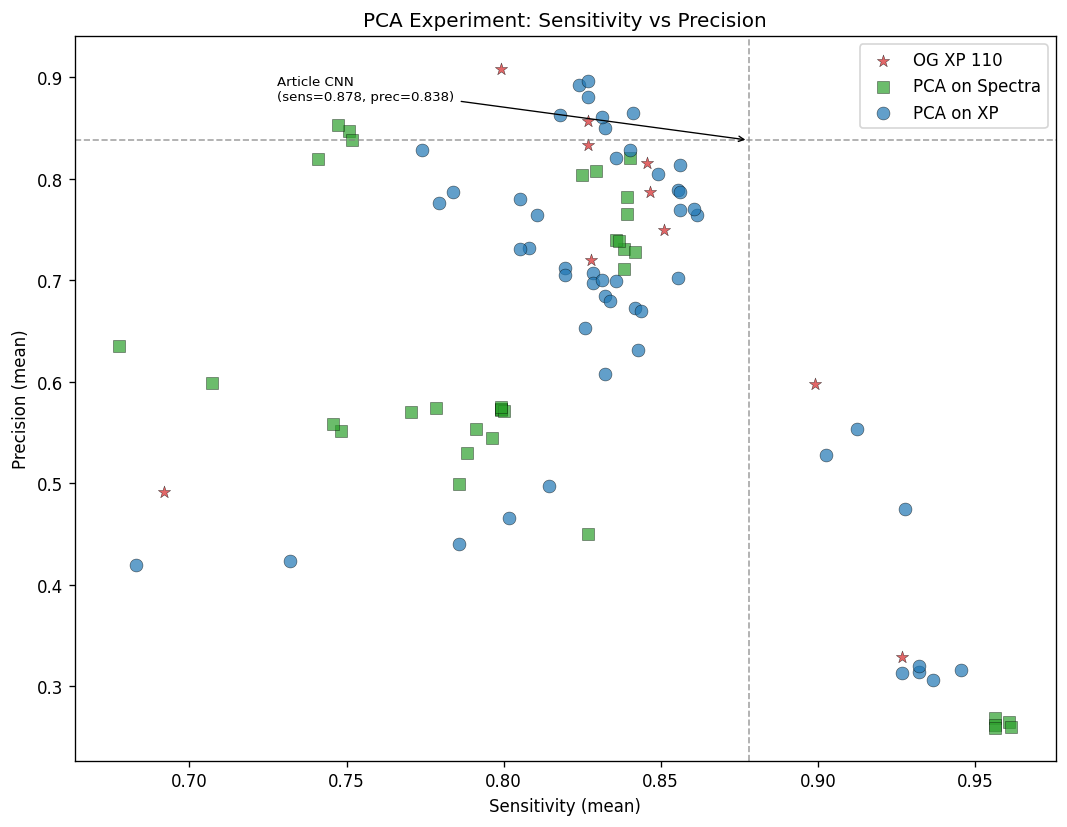

In [36]:
agg["group"] = agg["representation"].apply(
    lambda x: "OG XP 110" if x == "og_xp_110"
    else ("PCA on XP" if x.startswith("pca_xp") else "PCA on Spectra")
)

fig, ax = plt.subplots(figsize=(9, 7))

markers = {"OG XP 110": "*", "PCA on XP": "o", "PCA on Spectra": "s"}
colors = {"OG XP 110": "tab:red", "PCA on XP": "tab:blue", "PCA on Spectra": "tab:green"}

for grp, df_g in agg.groupby("group"):
    ax.scatter(
        df_g["sensitivity_mean"], df_g["precision_mean"],
        marker=markers[grp], color=colors[grp], label=grp,
        s=60, alpha=0.7, edgecolors="k", linewidths=0.3,
    )

ax.axhline(ART_PREC, ls="--", lw=1, color="gray", alpha=0.7)
ax.axvline(ART_SENS, ls="--", lw=1, color="gray", alpha=0.7)
ax.annotate(
    f"Article CNN\n(sens={ART_SENS}, prec={ART_PREC})",
    xy=(ART_SENS, ART_PREC), fontsize=8,
    xytext=(ART_SENS - 0.15, ART_PREC + 0.04),
    arrowprops=dict(arrowstyle="->", lw=0.8),
)

ax.set_xlabel("Sensitivity (mean)")
ax.set_ylabel("Precision (mean)")
ax.set_title("PCA Experiment: Sensitivity vs Precision")
ax.legend()
fig.tight_layout()
fig.savefig(RESULTS_DIR / "pca_sens_vs_prec.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Heatmaps: Sensitivity and Precision

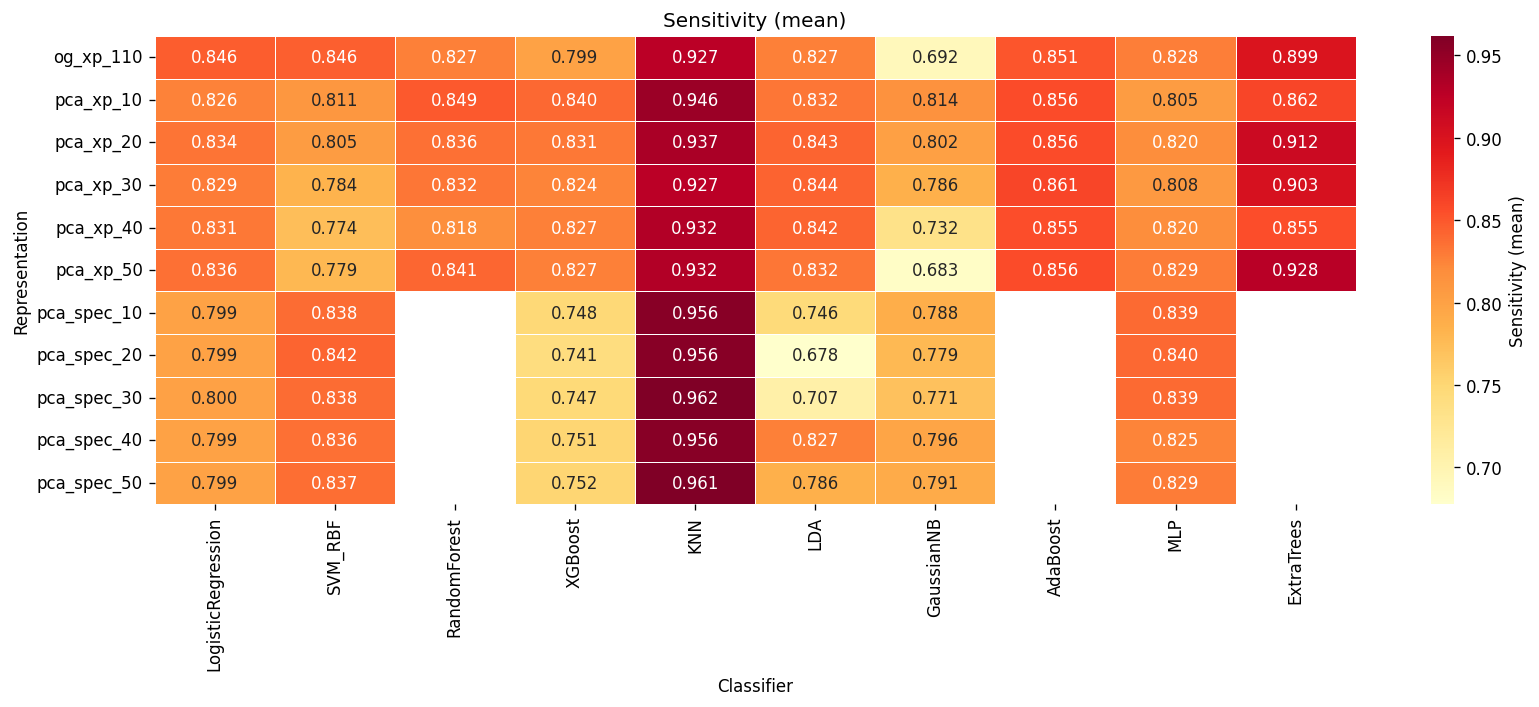

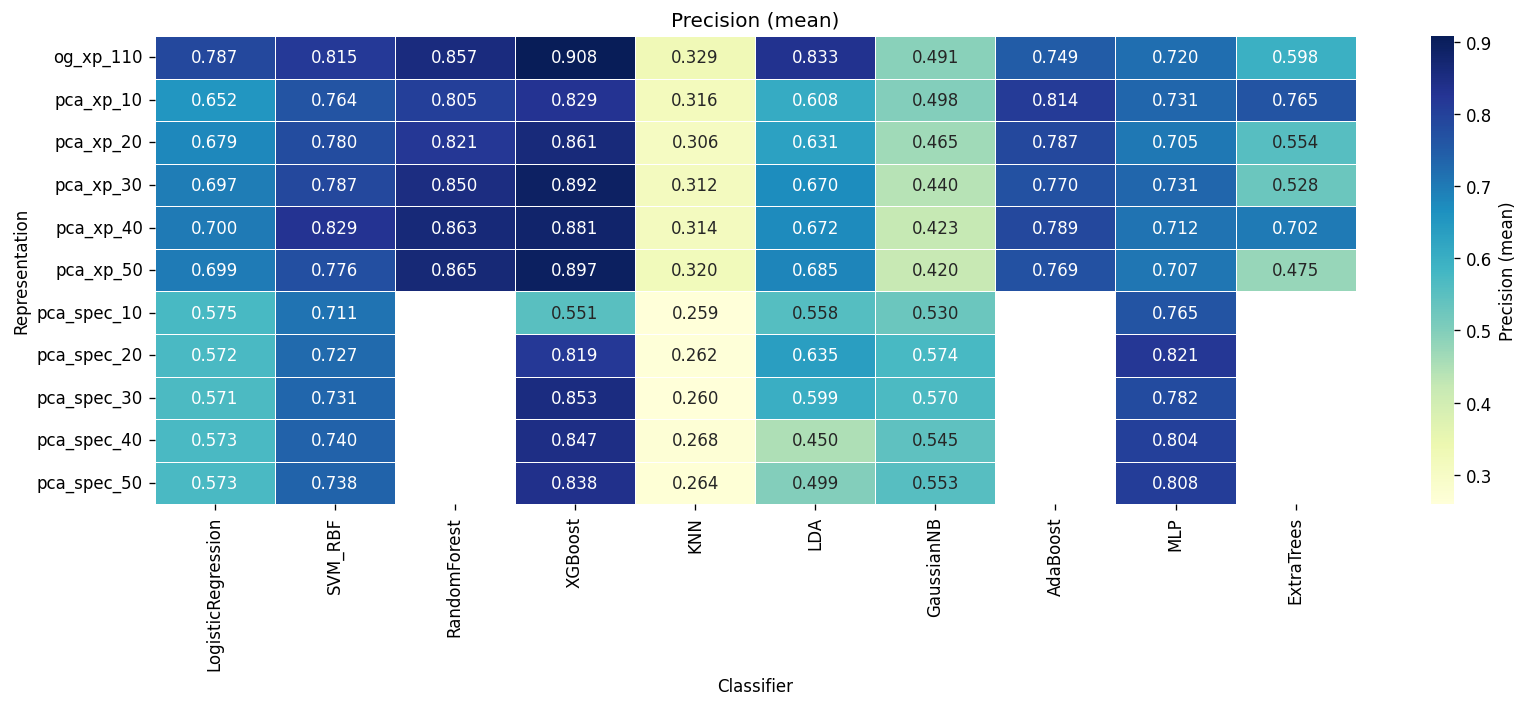

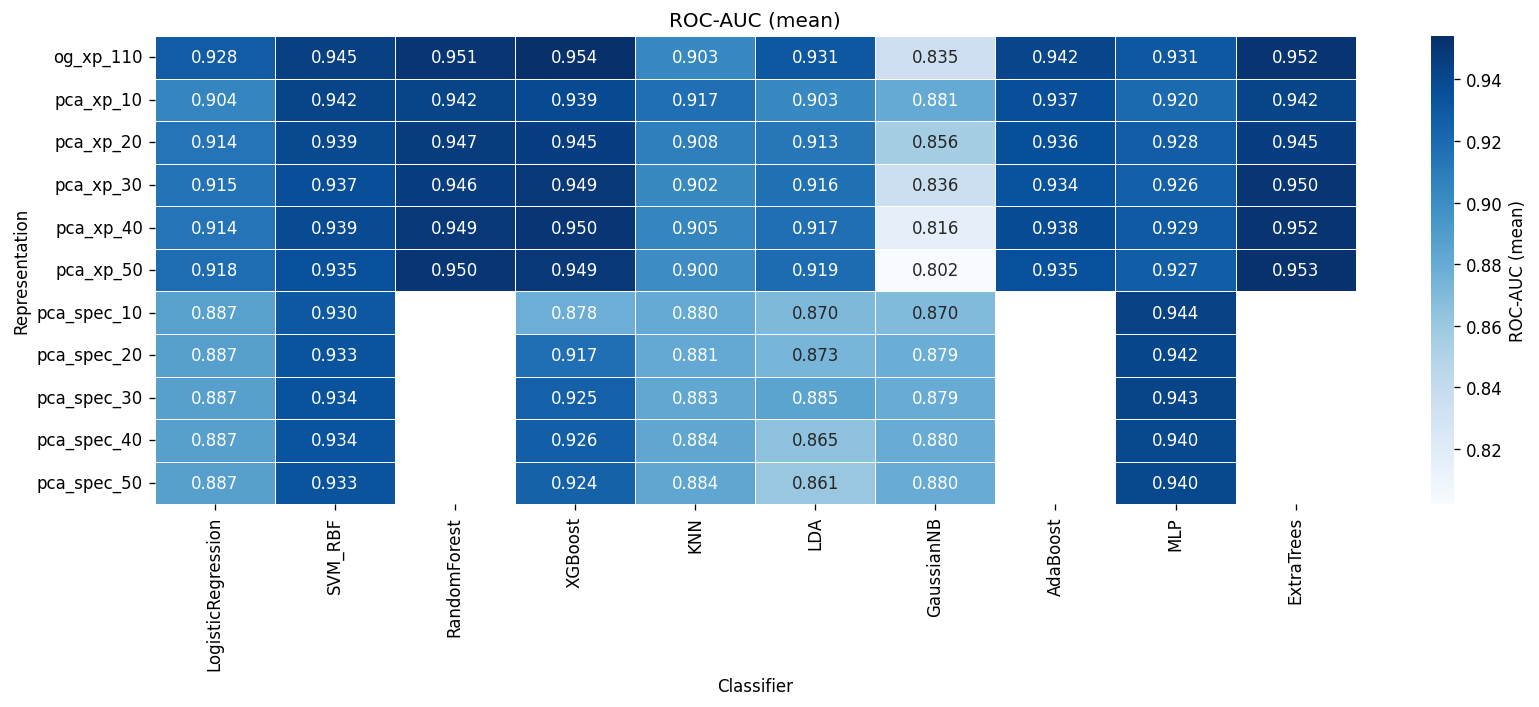

In [37]:
repr_order = ["og_xp_110"] + [f"pca_xp_{k}" for k in PCA_DIMS] + [f"pca_spec_{k}" for k in PCA_DIMS]
clf_order = [c["name"] for c in CLASSIFIERS]

for metric, cmap, title in [
    ("sensitivity_mean", "YlOrRd", "Sensitivity (mean)"),
    ("precision_mean", "YlGnBu", "Precision (mean)"),
    ("roc_auc_mean", "Blues", "ROC-AUC (mean)"),
]:
    pivot = agg.pivot_table(
        index="representation", columns="classifier", values=metric
    )
    pivot = pivot.reindex(index=repr_order, columns=clf_order)

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(
        pivot, annot=True, fmt=".3f", cmap=cmap, ax=ax,
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": title},
    )
    ax.set_title(title)
    ax.set_ylabel("Representation")
    ax.set_xlabel("Classifier")
    fig.tight_layout()
    fig.savefig(RESULTS_DIR / f"pca_heatmap_{metric.replace('_mean','')}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 8. Analysis: PCA vs Polynomial Experiment

Load the polynomial results from `02_classify` and merge for a combined comparison.

In [38]:
poly_results_path = RESULTS_DIR / "experiment_results.csv"
if poly_results_path.exists():
    df_poly = pd.read_csv(poly_results_path)
    df_poly["experiment"] = "polynomial"
    df_pca = df_results.copy()
    df_pca["experiment"] = "pca"

    df_combined = pd.concat([df_poly, df_pca], ignore_index=True)

    metric_cols_agg = ["roc_auc", "pr_auc", "youden_j", "f1",
                       "sensitivity", "specificity", "precision", "accuracy",
                       "brier", "log_loss"]
    combined_summary = (
        df_combined
        .groupby(["representation", "n_features", "classifier", "experiment"])[metric_cols_agg]
        .agg(["mean", "std"])
    )
    combined_summary.columns = [f"{c}_{s}" for c, s in combined_summary.columns]
    combined_summary = combined_summary.reset_index().sort_values("sensitivity_mean", ascending=False)

    degenerate = (combined_summary["roc_auc_mean"] <= 0.5) | (
        (combined_summary["sensitivity_mean"] >= 0.99) & (combined_summary["specificity_mean"] <= 0.01)
    )
    combined_summary = combined_summary[~degenerate].reset_index(drop=True)

    print(f"Combined results: {len(df_combined)} rows")
    print(f"\nTop 20 by Sensitivity (all experiments):")
    print(
        combined_summary[
            ["representation", "classifier", "experiment", "n_features",
             "sensitivity_mean", "sensitivity_std", "precision_mean", "precision_std",
             "roc_auc_mean"]
        ].head(20)
        .to_string(index=False)
    )
else:
    print("Polynomial experiment results not found — skipping combined analysis.")
    combined_summary = None

Combined results: 3560 rows

Top 20 by Sensitivity (all experiments):
  representation         classifier experiment  n_features  sensitivity_mean  sensitivity_std  precision_mean  precision_std  roc_auc_mean
 laguerre_40_raw       RandomForest polynomial          40          0.995536         0.004706        0.200147       0.001072      0.502775
 laguerre_30_raw       RandomForest polynomial          30          0.994643         0.004611        0.200219       0.001284      0.502555
 laguerre_20_raw       RandomForest polynomial          20          0.989286         0.005647        0.200879       0.001403      0.506451
  hermite_20_raw       RandomForest polynomial          20          0.985714         0.010480        0.200218       0.001894      0.507245
 laguerre_40_raw         GaussianNB polynomial          40          0.979464         0.015205        0.201297       0.002457      0.508649
 laguerre_50_raw       RandomForest polynomial          50          0.979464         0.011942   

## 9. Variance Explained vs Classification Performance

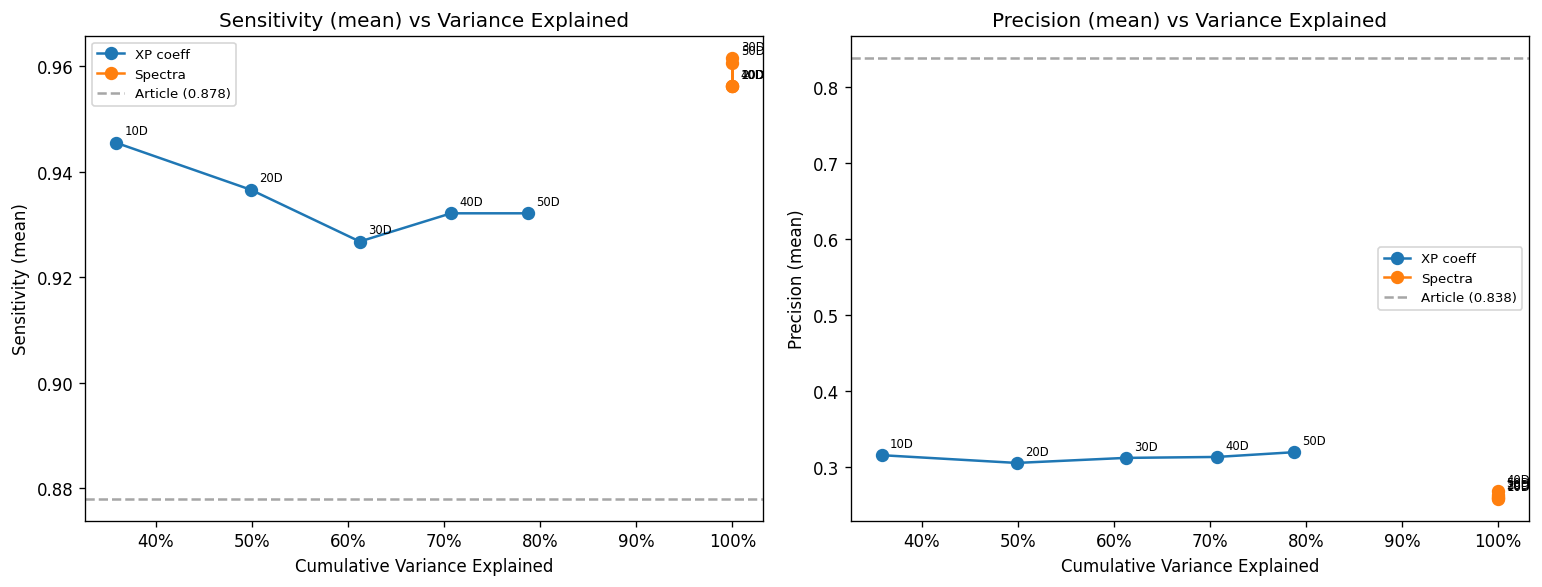

Saved → results/pca_variance_vs_performance.png


In [39]:
pca_only = agg[agg["representation"].str.startswith("pca_")].copy()
pca_only["source"] = pca_only["representation"].apply(
    lambda x: "XP coeff" if "xp" in x else "Spectra"
)

var_map = {}
for _, row in df_var.iterrows():
    k = int(row["n_components"])
    var_map[f"pca_xp_{k}"] = row["xp_110d_cumvar"]
    var_map[f"pca_spec_{k}"] = row["spec_343d_cumvar"]

pca_only["cum_var"] = pca_only["representation"].map(var_map)

best_per_repr = pca_only.sort_values("sensitivity_mean", ascending=False).drop_duplicates("representation")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, metric, label in [
    (axes[0], "sensitivity_mean", "Sensitivity (mean)"),
    (axes[1], "precision_mean", "Precision (mean)"),
]:
    for src in ["XP coeff", "Spectra"]:
        mask = best_per_repr["source"] == src
        sub = best_per_repr[mask].sort_values("cum_var")
        ax.plot(sub["cum_var"], sub[metric], "o-", label=src, ms=7)
        for _, row in sub.iterrows():
            ax.annotate(
                f"{int(row['n_features'])}D",
                (row["cum_var"], row[metric]),
                textcoords="offset points", xytext=(5, 5), fontsize=7,
            )

    if metric == "sensitivity_mean":
        ax.axhline(ART_SENS, ls="--", color="gray", alpha=0.7, label=f"Article ({ART_SENS})")
    else:
        ax.axhline(ART_PREC, ls="--", color="gray", alpha=0.7, label=f"Article ({ART_PREC})")

    ax.set_xlabel("Cumulative Variance Explained")
    ax.set_ylabel(label)
    ax.set_title(f"{label} vs Variance Explained")
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))

fig.tight_layout()
fig.savefig(RESULTS_DIR / "pca_variance_vs_performance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → results/pca_variance_vs_performance.png")

## 10. Summary

In [40]:
print("=" * 90)
print("PCA EXPERIMENT — SUMMARY")
print("=" * 90)

print(f"\nArticle baseline (CNN Binary, Youden): Sensitivity={ART_SENS}, Precision={ART_PREC}")
print(f"Total configurations: {len(agg)}")

beats_sens = agg[agg["sensitivity_mean"] >= ART_SENS]
beats_prec = agg[agg["precision_mean"] >= ART_PREC]
beats_both = agg[(agg["sensitivity_mean"] >= ART_SENS) & (agg["precision_mean"] >= ART_PREC)]

print(f"\nConfigurations beating article sensitivity ({ART_SENS}): {len(beats_sens)}")
print(f"Configurations beating article precision ({ART_PREC}):    {len(beats_prec)}")
print(f"Configurations beating BOTH:                              {len(beats_both)}")

if len(beats_both) > 0:
    print("\nConfigurations beating both sensitivity and precision:")
    print(
        beats_both.sort_values(["sensitivity_mean", "precision_mean"], ascending=[False, False])[
            ["representation", "classifier", "n_features",
             "sensitivity_mean", "sensitivity_std", "precision_mean", "precision_std",
             "roc_auc_mean"]
        ].to_string(index=False)
    )

print("\n" + "=" * 90)
print("Best per representation group (by sensitivity):")
print("=" * 90)

for grp_name, grp_repr in [("OG XP 110", ["og_xp_110"]),
                             ("PCA on XP coeff", [f"pca_xp_{k}" for k in PCA_DIMS]),
                             ("PCA on Spectra", [f"pca_spec_{k}" for k in PCA_DIMS])]:
    sub = agg[agg["representation"].isin(grp_repr)].sort_values(
        ["sensitivity_mean", "precision_mean"], ascending=[False, False]
    ).head(3)
    print(f"\n--- {grp_name} ---")
    for _, row in sub.iterrows():
        print(
            f"  {row['representation']:20s} + {row['classifier']:20s}  "
            f"Sens={row['sensitivity_mean']:.4f}±{row['sensitivity_std']:.4f}  "
            f"Prec={row['precision_mean']:.4f}±{row['precision_std']:.4f}  "
            f"AUC={row['roc_auc_mean']:.4f}"
        )

print("\nDone. See results/ for all outputs.")

PCA EXPERIMENT — SUMMARY

Article baseline (CNN Binary, Youden): Sensitivity=0.878, Precision=0.838
Total configurations: 95

Configurations beating article sensitivity (0.878): 15
Configurations beating article precision (0.838):    12
Configurations beating BOTH:                              0

Best per representation group (by sensitivity):

--- OG XP 110 ---
  og_xp_110            + KNN                   Sens=0.9268±0.0187  Prec=0.3290±0.0231  AUC=0.9028
  og_xp_110            + ExtraTrees            Sens=0.8991±0.0890  Prec=0.5975±0.3182  AUC=0.9517
  og_xp_110            + AdaBoost              Sens=0.8509±0.0329  Prec=0.7495±0.0534  AUC=0.9419

--- PCA on XP coeff ---
  pca_xp_10            + KNN                   Sens=0.9455±0.0240  Prec=0.3160±0.0311  AUC=0.9171
  pca_xp_20            + KNN                   Sens=0.9366±0.0308  Prec=0.3058±0.0216  AUC=0.9083
  pca_xp_50            + KNN                   Sens=0.9321±0.0332  Prec=0.3200±0.0374  AUC=0.9000

--- PCA on Spectra --